# Notebook 03 — Análisis exploratorio (EDA)

## Planteamiento de trabajo

En esta etapa exploramos el dataset ya limpio para **entender el comportamiento de los usuarios** antes de aplicar técnicas más avanzadas. El análisis se organiza en tres niveles: **univariado** (una variable por vez), **bivariado** (relación entre dos) y **multivariado** (varias a la vez).

Siguiendo la consigna, **cada visualización responde a una pregunta concreta** y termina con una interpretación que explica qué evidencia aporta, no que solo describe el gráfico.

**Preguntas que guían el análisis:**

- ¿Cómo se distribuye el tiempo mensual de visualización?
- ¿Cómo se reparten los usuarios entre los planes de suscripción?
- ¿La edad se relaciona con el tiempo de visualización?
- ¿El tiempo de visualización varía según el plan?
- ¿Varía según el género favorito?
- ¿Cómo se relacionan entre sí las variables numéricas?

## Carga y preparación de los datos

### Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Se importan pandas y numpy para los datos, y matplotlib y seaborn para las visualizaciones.

### Carga del dataset limpio

In [2]:
df = pd.read_csv("../data/processed/streaming_users_processed.csv")

Se carga el dataset ya procesado en el Notebook 02, desde `data/processed/`.

### Vista previa

In [3]:
df.head()

,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10000,39.0,Estándar,805.8,Brasil,Crime,2025-03-04,1
1,10001,37.0,Estándar,1173.4,Colombia,Crime,2019-04-02,2
2,10002,28.0,Básico,401.0,Colombia,Crime,2018-04-13,0
3,10003,43.0,Básico,62.4,Uruguay,Thriller,2021-01-31,0
4,10004,51.0,Básico,477.8,Perú,Thriller,2020-09-30,1


La vista previa confirma que el dataset llega limpio y listo para analizar.

### Dimensiones

In [4]:
df.shape

(8034, 8)

El dataset tiene 8034 filas y 8 columnas.

### Estructura y tipos de dato

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8034 entries, 0 to 8033
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   8034 non-null   int64  
 1   age                       8034 non-null   float64
 2   subscription_plan         8034 non-null   str    
 3   monthly_watch_time_mins   8034 non-null   float64
 4   country                   8034 non-null   str    
 5   favorite_genre            8034 non-null   str    
 6   last_login_date           7548 non-null   str    
 7   customer_support_tickets  8034 non-null   int64  
dtypes: float64(2), int64(2), str(4)
memory usage: 502.3 KB


Confirmamos los tipos de cada variable. La fecha de último ingreso figura como texto, así que la convertimos.

### Conversión de la fecha

In [6]:
df["last_login_date"] = pd.to_datetime(
    df["last_login_date"],
    errors="coerce"
)

Pasamos `last_login_date` a tipo fecha real para poder trabajarla correctamente.

### Verificación de tipos

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8034 entries, 0 to 8033
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   user_id                   8034 non-null   int64         
 1   age                       8034 non-null   float64       
 2   subscription_plan         8034 non-null   str           
 3   monthly_watch_time_mins   8034 non-null   float64       
 4   country                   8034 non-null   str           
 5   favorite_genre            8034 non-null   str           
 6   last_login_date           7548 non-null   datetime64[us]
 7   customer_support_tickets  8034 non-null   int64         
dtypes: datetime64[us](1), float64(2), int64(2), str(3)
memory usage: 502.3 KB


La fecha ya quedó como fecha (datetime) y el resto de las variables está en su tipo correcto.

## Análisis univariado 1: Distribución del tiempo mensual de visualización

Objetivo

Analizar cómo se distribuye el tiempo mensual de visualización (monthly_watch_time_mins) entre los usuarios de la plataforma.

Este análisis responde a la pregunta:

**¿Cómo se distribuye el tiempo mensual de visualización de los usuarios?**

Estadísticas descriptivas:


count    8034.00
mean      801.35
std       489.96
min         0.00
25%       499.68
50%       771.60
75%      1059.40
max      4193.70
Name: monthly_watch_time_mins, dtype: float64

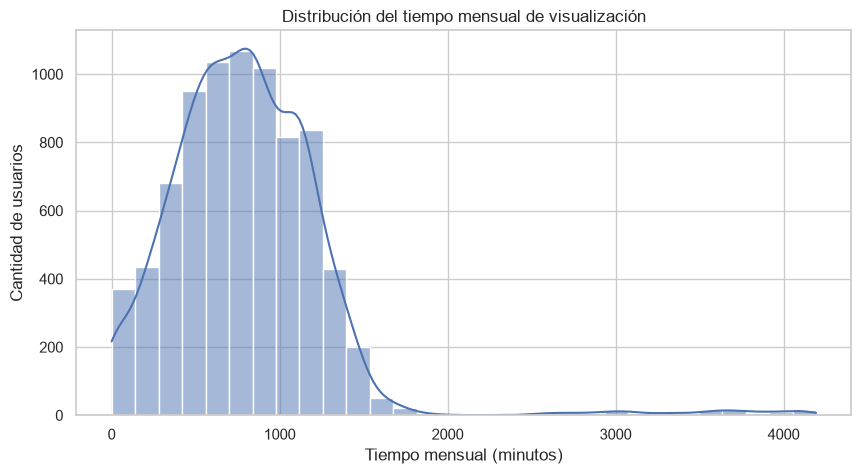

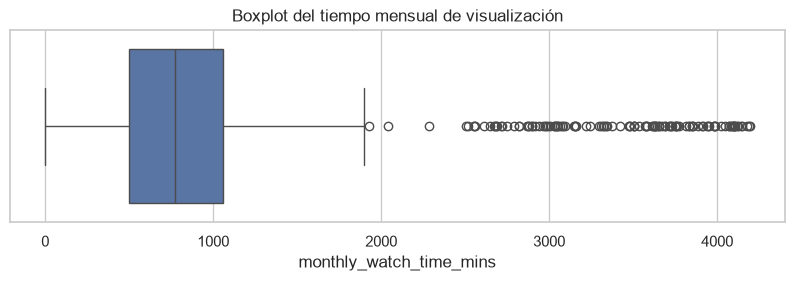

In [9]:
# Configuración estética
sns.set_theme(style="whitegrid")

# Estadísticas descriptivas

print("Estadísticas descriptivas:")
display(df["monthly_watch_time_mins"].describe().round(2))

# Histograma

plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="monthly_watch_time_mins",
    bins=30,
    kde=True
)

plt.title("Distribución del tiempo mensual de visualización")
plt.xlabel("Tiempo mensual (minutos)")
plt.ylabel("Cantidad de usuarios")

plt.show()

# Boxplot


plt.figure(figsize=(10,2.5))

sns.boxplot(
    x=df["monthly_watch_time_mins"]
)

plt.title("Boxplot del tiempo mensual de visualización")

plt.show()

El tiempo mensual de visualización presenta una distribución asimétrica hacia la derecha. La mayor parte de los usuarios concentra su consumo entre aproximadamente 500 y 1200 minutos mensuales, mientras que un grupo reducido registra tiempos considerablemente superiores. El boxplot evidencia la presencia de valores atípicos, aunque no existe evidencia que indique que correspondan a errores del dataset, por lo que se conservaron para representar el comportamiento real de los usuarios. La diferencia entre la media (801,35 minutos) y la mediana (771,60 minutos) también refleja la influencia de estos usuarios con consumos elevados.

## Análisis univariado 2: Distribución de los planes de suscripción

Objetivo

Analizar cómo se distribuyen los usuarios entre los distintos planes de suscripción disponibles en la plataforma.

Responderemos la pregunta:

**¿Cuál es la distribución de los planes de suscripción entre los usuarios?**

Frecuencia absoluta:


subscription_plan
Básico      3609
Estándar    2833
Premium     1592
Name: count, dtype: int64


Frecuencia relativa (%):


subscription_plan
Básico      44.92
Estándar    35.26
Premium     19.82
Name: proportion, dtype: float64

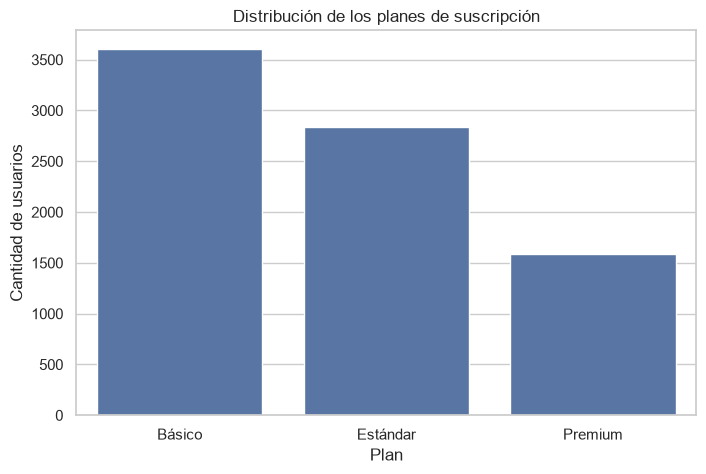

In [10]:
# Frecuencia de los planes de suscripción


# Frecuencia absoluta
frecuencia_planes = df["subscription_plan"].value_counts()

# Frecuencia relativa (%)
porcentaje_planes = (
    df["subscription_plan"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Frecuencia absoluta:")
display(frecuencia_planes)

print("\nFrecuencia relativa (%):")
display(porcentaje_planes)


# Gráfico de barras

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="subscription_plan",
    order=frecuencia_planes.index
)

plt.title("Distribución de los planes de suscripción")
plt.xlabel("Plan")
plt.ylabel("Cantidad de usuarios")

plt.show()

La distribución de los planes de suscripción muestra que el plan Básico es el más utilizado, concentrando el 44,92 % de los usuarios. Le sigue el plan Estándar con el 35,26 %, mientras que el plan Premium representa el 19,82 % del total. La diferencia entre las categorías indica una mayor preferencia por los planes de menor costo, aunque los tres grupos cuentan con una cantidad suficiente de usuarios para realizar comparaciones en los análisis posteriores.

## Análisis bivariado 1: Edad vs. Tiempo mensual de visualización

Objetivo

Analizar si existe una relación entre la edad de los usuarios (age) y el tiempo mensual de visualización (monthly_watch_time_mins).

Responderemos la pregunta:

**¿Existe relación entre la edad del usuario y el tiempo mensual de visualización?**

Coeficiente de correlación de Pearson: 0.005


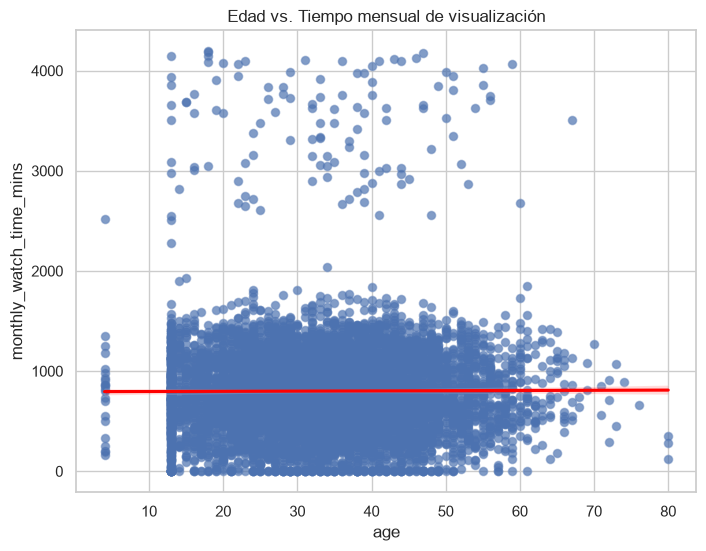

In [11]:
# Correlación entre edad y tiempo de visualización

correlacion = df["age"].corr(df["monthly_watch_time_mins"])

print(f"Coeficiente de correlación de Pearson: {correlacion:.3f}")

# Diagrama de dispersión

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="age",
    y="monthly_watch_time_mins",
    alpha=0.5
)

plt.title("Edad vs. Tiempo mensual de visualización")
plt.xlabel("Edad")
plt.ylabel("Tiempo mensual de visualización (minutos)")

sns.regplot(
    data=df,
    x="age",
    y="monthly_watch_time_mins",
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"}
)

plt.show()

El análisis de la relación entre la edad y el tiempo mensual de visualización no evidencia una asociación lineal significativa. El coeficiente de correlación de Pearson fue 0,005, indicando una correlación prácticamente nula entre ambas variables. La línea de regresión presenta una pendiente casi horizontal, reforzando la ausencia de una tendencia creciente o decreciente del tiempo de visualización en función de la edad. En consecuencia, la edad no constituye un factor determinante del consumo mensual de contenido en este conjunto de datos.

## Análisis bivariado 2: tiempo de visualización según el plan


Objetivo

Analizar si los usuarios que poseen distintos planes de suscripción presentan diferencias en el tiempo mensual de visualización (monthly_watch_time_mins).

Responderemos la pregunta:

**¿El tiempo mensual de visualización varía según el plan de suscripción?**

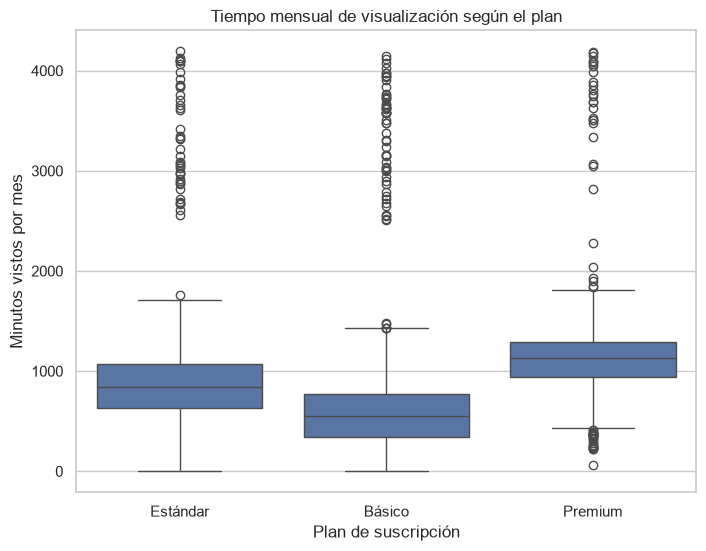

In [12]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="subscription_plan",
    y="monthly_watch_time_mins"
)

plt.title("Tiempo mensual de visualización según el plan")
plt.xlabel("Plan de suscripción")
plt.ylabel("Minutos vistos por mes")

plt.show()

El boxplot muestra diferencias en el tiempo mensual de visualización según el plan de suscripción. Los usuarios del plan Premium presentan la mayor mediana de minutos vistos por mes, seguidos por los usuarios del plan Estándar y, finalmente, por los del plan Básico. Además, se observan numerosos valores atípicos en los tres grupos, correspondientes a usuarios con consumos muy elevados. Si bien existe una tendencia creciente del tiempo de visualización al aumentar el nivel del plan, las distribuciones presentan cierta superposición, indicando que el plan de suscripción no es el único factor que influye en el consumo.

Conclusión

A partir de la inspección visual, parece existir una diferencia en el tiempo mensual de visualización entre los distintos planes de suscripción, siendo el plan Premium el que concentra, en promedio, un mayor consumo de contenido.

Sin embargo, esta conclusión es descriptiva. Para respaldarla con datos objetivos, el siguiente paso será calcular estadísticas descriptivas (como media, mediana y desviación estándar) para cada plan y verificar si las diferencias observadas en el gráfico se reflejan en los valores numéricos. No adelantaremos otras pruebas hasta completar ese paso.

### Estadísticas descriptivas por plan de suscripción

In [13]:
estadisticas_plan = (
    df
    .groupby("subscription_plan")["monthly_watch_time_mins"]
    .describe().round(2)
)

estadisticas_plan

,count,mean,std,min,25%,50%,75%,max
subscription_plan,,,,,,,,
Básico,3609.0,597.06,458.57,0.0,343.0,552.45,776.20,4142.6
Estándar,2833.0,871.59,436.11,0.0,626.9,840.50,1071.40,4193.7
Premium,1592.0,1139.49,422.82,66.1,940.1,1127.15,1290.32,4188.7


Las estadísticas descriptivas muestran que el tiempo mensual de visualización aumenta conforme el nivel del plan de suscripción. Los usuarios del plan Premium presentan el mayor promedio (1139,49 minutos) y la mayor mediana (1127,15 minutos), seguidos por los planes Estándar y Básico. Además, los cuartiles también evidencian un incremento progresivo del consumo entre los distintos planes. Si bien los tres grupos presentan una dispersión similar y existen valores atípicos de consumo elevado, la tendencia general indica que los usuarios con planes superiores dedican más tiempo al consumo de contenido en la plataforma.

Conclusión

Podemos responder a la pregunta de análisis:

Sí, el tiempo mensual de visualización varía según el plan de suscripción. En términos descriptivos, los usuarios del plan Premium registran el mayor nivel de consumo, seguidos por los usuarios del plan Estándar y, finalmente, por los del plan Básico. Tanto el boxplot como las estadísticas descriptivas muestran una tendencia consistente de aumento del tiempo de visualización conforme se incrementa el nivel del plan.

## Análisis bivariado 3: tiempo de visualización según el género

Objetivo

Analizar si el género favorito (favorite_genre) de los usuarios se relaciona con el tiempo mensual de visualización (monthly_watch_time_mins).

Responderemos la pregunta:

¿El tiempo mensual de visualización varía según el género favorito?

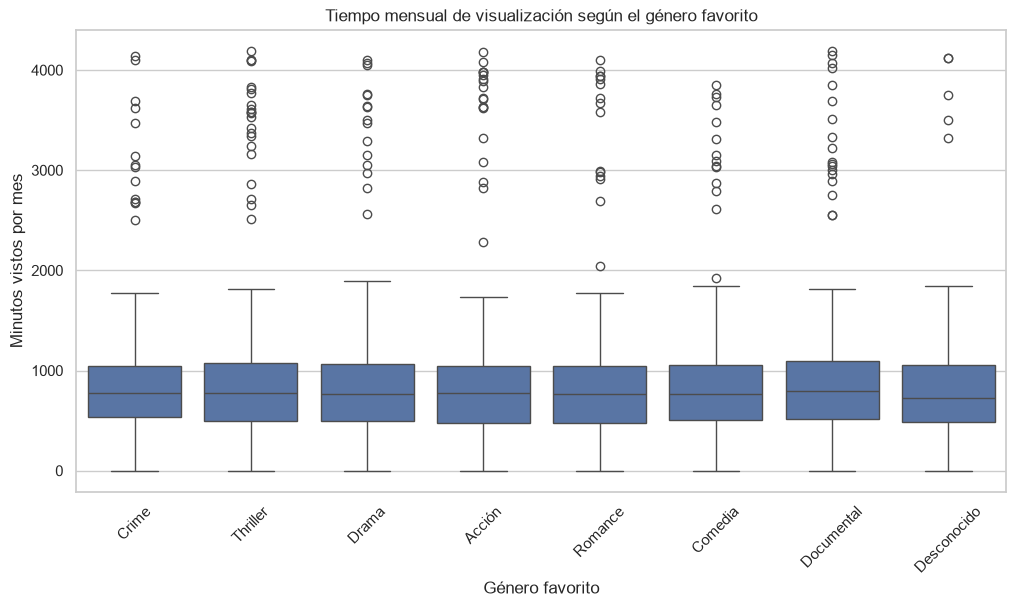

In [14]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="favorite_genre",
    y="monthly_watch_time_mins"
)

plt.title("Tiempo mensual de visualización según el género favorito")
plt.xlabel("Género favorito")
plt.ylabel("Minutos vistos por mes")

plt.xticks(rotation=45)

plt.show()

El boxplot muestra que el tiempo mensual de visualización presenta distribuciones similares entre los distintos géneros favoritos. Las medianas y la dispersión son comparables en la mayoría de las categorías, observándose una importante superposición entre las distribuciones. Además, existen valores atípicos en todos los grupos, correspondientes a usuarios con tiempos de visualización excepcionalmente elevados. En conjunto, el gráfico no evidencia diferencias marcadas en el consumo mensual según el género favorito.

Conclusión

La inspección visual sugiere que el género favorito no parece ser un factor determinante del tiempo mensual de visualización. A diferencia de lo observado con el plan de suscripción, no se identifican diferencias claras entre los distintos géneros.

## Análisis multivariado

Objetivo

Analizar de manera conjunta las relaciones existentes entre las variables numéricas del conjunto de datos para identificar posibles asociaciones.

Responderemos la pregunta:

¿Cómo se relacionan entre sí las variables numéricas del dataset?


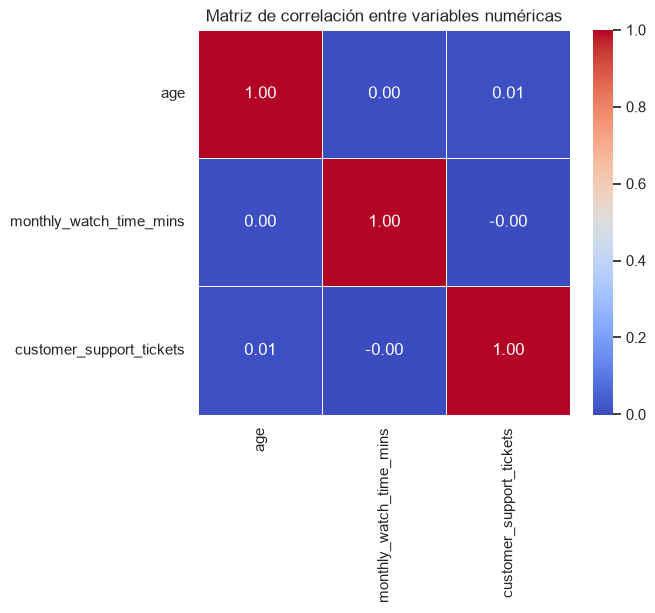

In [15]:
# Seleccionar variables numéricas excluyendo el identificador
variables_numericas = df.select_dtypes(include="number").drop(columns="user_id")

# Calcular la matriz de correlación
matriz_correlacion = variables_numericas.corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriz de correlación entre variables numéricas")

plt.show()
plt.show()

La matriz de correlación evidencia que las variables numéricas del conjunto de datos presentan correlaciones lineales muy débiles o prácticamente inexistentes. La edad no muestra una relación significativa con el tiempo mensual de visualización, resultado que coincide con el análisis bivariado realizado previamente. Asimismo, la cantidad de tickets de soporte tampoco presenta una asociación lineal con el tiempo de visualización. En conjunto, estos resultados indican que las variables numéricas analizadas son relativamente independientes entre sí y que el comportamiento de consumo no puede explicarse mediante una única variable numérica.

Conclusión

El análisis multivariado muestra que las variables numéricas del dataset no presentan relaciones lineales relevantes entre sí. Esto sugiere que el tiempo mensual de visualización depende de múltiples factores y que variables categóricas, como el plan de suscripción, aportan mayor capacidad descriptiva que las variables numéricas analizadas.

## Conclusión general del EDA

Conclusiones del Análisis Exploratorio

Durante el análisis exploratorio se estudiaron las principales variables del conjunto de datos mediante análisis univariado, bivariado y multivariado.

Los resultados muestran que:

El tiempo mensual de visualización presenta una distribución con usuarios de consumo muy elevado, considerados comportamientos válidos y conservados durante la preparación de los datos.
El plan de suscripción muestra una relación con el tiempo de visualización, observándose un mayor consumo en los usuarios del plan Premium.
La edad no presenta una relación lineal significativa con el tiempo mensual de visualización.
El género favorito tampoco evidencia diferencias importantes en el nivel de consumo entre los distintos grupos.
La matriz de correlación indica que las variables numéricas presentan relaciones lineales muy débiles, sugiriendo que el comportamiento de los usuarios depende de múltiples factores y no de una única variable numérica.

En conjunto, el análisis exploratorio permitió responder las preguntas planteadas al inicio del proyecto y obtener evidencia para comprender el comportamiento general de los usuarios antes de aplicar técnicas de reducción de dimensionalidad.